In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import datasets, transforms

# Part 1: Dataset Understanding and Inspection

Load the dataset and check the **class distribution per split**.

In [2]:
data_dir = Path("/kaggle/input/competitions/artificial-intelligencefor-histopathology/Histo images")

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

for split in [train_dir, val_dir, test_dir]:
    print(f"\n{split.name} classes:")
    for cls in os.listdir(split):
        n = len(os.listdir(split / cls))
        print(f"{cls}: {n} images")


train classes:
Onco: 1500 images
normal: 1500 images
pRCC: 1500 images
ccRCC: 1500 images
Chromo: 1500 images

val classes:
Onco: 300 images
normal: 300 images
pRCC: 300 images
ccRCC: 300 images
Chromo: 300 images

test classes:
Onco: 697 images
normal: 1800 images
pRCC: 1800 images
ccRCC: 1800 images
Chromo: 542 images


In [3]:
def show_random_images(folder, n=6):
    #TODO
    image_files = []
    
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                image_files.append(os.path.join(root, file))
    
    if len(image_files) == 0:
        print("No images found in the folder.")
        return
    
    n = min(n, len(image_files))
    selected_images = random.sample(image_files, n)
    
    plt.figure(figsize=(15, 8))
    
    for i, img_path in enumerate(selected_images, 1):
        img = Image.open(img_path).convert("RGB")
        class_name = os.path.basename(os.path.dirname(img_path))
        
        plt.subplot(2, (n + 1) // 2, i)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

## Create Datasets

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [6]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

from PIL import Image

def remove_corrupted(dataset):

    valid_samples = []

    for path, label in dataset.samples:

        try:
            img = Image.open(path)
            img.verify()   # check image integrity
            valid_samples.append((path, label))

        except:
            print("Removing corrupted image:", path)

    dataset.samples = valid_samples
    dataset.imgs = valid_samples

remove_corrupted(train_dataset)
remove_corrupted(val_dataset)
remove_corrupted(test_dataset)

Removing corrupted image: /kaggle/input/competitions/artificial-intelligencefor-histopathology/Histo images/train/Chromo/1526.png


In [8]:
from torch.utils.data import DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First labels:", labels[:10])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First labels: tensor([0, 4, 2, 0, 4, 2, 1, 2, 0, 0])


# Part 2: Baseline classifier with handcrafted features

Define handmade features


In [10]:
import numpy as np
from PIL import Image

def extract_features(img):
    # Convert PIL image to numpy array
    img = np.array(img).astype(np.float32) / 255.0   # normalize to [0, 1]
    
    # RGB channel statistics
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]
    
    color_features = [
        r.mean(), g.mean(), b.mean(),
        r.std(), g.std(), b.std(),
        r.min(), g.min(), b.min(),
        r.max(), g.max(), b.max()
    ]
    
    # Convert to grayscale manually
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    
    # Grayscale intensity statistics
    gray_features = [
        gray.mean(),
        gray.std(),
        gray.min(),
        gray.max(),
        np.median(gray)
    ]
    
    # Simple edge-based features using gradients
    gx = np.diff(gray, axis=1)
    gy = np.diff(gray, axis=0)
    
    edge_mean_x = np.mean(np.abs(gx))
    edge_std_x = np.std(np.abs(gx))
    edge_mean_y = np.mean(np.abs(gy))
    edge_std_y = np.std(np.abs(gy))
    
    edge_features = [
        edge_mean_x,
        edge_std_x,
        edge_mean_y,
        edge_std_y
    ]
    
    # Final feature vector
    features = np.array(color_features + gray_features + edge_features, dtype=np.float32)
    
    return features

In [11]:
X_train = []
y_train = []

for i in range(len(train_dataset)):

    try:
        img, label = train_dataset[i]

        img = img.permute(1,2,0).numpy()
        img = (img*255).astype(np.uint8)

        features = extract_features(img)

        X_train.append(features)
        y_train.append(label)

    except:
        continue

X_train = np.array(X_train)
y_train = np.array(y_train)

print("Train feature matrix:", X_train.shape)

Train feature matrix: (7499, 21)


In [12]:
X_test = []
y_test = []

for i in range(len(test_dataset)):

    try:
        img, label = test_dataset[i]

        img = img.permute(1,2,0).numpy()
        img = (img*255).astype(np.uint8)

        features = extract_features(img)

        X_test.append(features)
        y_test.append(label)

    except:
        continue

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test feature matrix:", X_test.shape)

Test feature matrix: (6639, 21)


In [13]:
X_val = []
y_val = []

for i in range(len(val_dataset)):

    try:
        img, label = val_dataset[i]

        img = img.permute(1,2,0).numpy()
        img = (img*255).astype(np.uint8)

        features = extract_features(img)

        X_val.append(features)
        y_val.append(label)

    except:
        continue

X_val = np.array(X_val)
y_val = np.array(y_val)

print("Validation feature matrix:", X_val.shape)

Validation feature matrix: (1500, 21)


In [14]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [15]:
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)
test_data = TensorDataset(X_test, y_test)

from PIL import Image

def remove_corrupted(dataset):

    valid_samples = []

    for path, label in dataset.samples:

        try:
            img = Image.open(path)
            img.verify()   # check image integrity
            valid_samples.append((path, label))

        except:
            print("Removing corrupted image:", path)

    dataset.samples = valid_samples
    dataset.imgs = valid_samples

remove_corrupted(train_dataset)
remove_corrupted(val_dataset)
remove_corrupted(test_dataset)


train_loader_features = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader_features = DataLoader(val_data, batch_size=64)
test_loader_features = DataLoader(test_data, batch_size=64,shuffle=False)

Define a classifier

In [16]:
import torch.nn as nn

class FeatureClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(21, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 5)
        )

    def forward(self, x):
        return self.net(x)

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = FeatureClassifier().to(device)

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader_features:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * features.size(0)

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader_features:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * features.size(0)

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/50] | Train Loss: 1.6017 | Train Acc: 0.2364 | Val Loss: 1.5782 | Val Acc: 0.3653
Epoch [2/50] | Train Loss: 1.5141 | Train Acc: 0.3179 | Val Loss: 1.3894 | Val Acc: 0.3893
Epoch [3/50] | Train Loss: 1.2935 | Train Acc: 0.3841 | Val Loss: 1.1695 | Val Acc: 0.4373
Epoch [4/50] | Train Loss: 1.1499 | Train Acc: 0.4055 | Val Loss: 1.0992 | Val Acc: 0.4053
Epoch [5/50] | Train Loss: 1.1020 | Train Acc: 0.4046 | Val Loss: 1.0739 | Val Acc: 0.4047
Epoch [6/50] | Train Loss: 1.0755 | Train Acc: 0.4117 | Val Loss: 1.0578 | Val Acc: 0.4120
Epoch [7/50] | Train Loss: 1.0603 | Train Acc: 0.4291 | Val Loss: 1.0428 | Val Acc: 0.4373
Epoch [8/50] | Train Loss: 1.0471 | Train Acc: 0.4239 | Val Loss: 1.0388 | Val Acc: 0.4533
Epoch [9/50] | Train Loss: 1.0442 | Train Acc: 0.4257 | Val Loss: 1.0302 | Val Acc: 0.4540
Epoch [10/50] | Train Loss: 1.0367 | Train Acc: 0.4298 | Val Loss: 1.0282 | Val Acc: 0.4407
Epoch [11/50] | Train Loss: 1.0279 | Train Acc: 0.4378 | Val Loss: 1.0203 | Val Acc: 0.44

In [20]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in val_loader_features:

        x = x.to(device)
        y = y.to(device)

        outputs = model(x)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = correct / total

print("Validation accuracy:", accuracy)

Validation accuracy: 0.554


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score

def collect_preds(model, loader, device):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

def cm_with_percent_labels(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    labels = np.array([
        f"{cm[i,j]}\n{cm_percent[i,j]:.1f}%"
        for i in range(n_classes)
        for j in range(n_classes)
    ]).reshape(n_classes, n_classes)

    return cm, labels

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

In [22]:
class_names = train_dataset.classes
n_classes = len(class_names)

y_val_true, y_val_pred = collect_preds(model, val_loader_features, device)
y_test_true, y_test_pred = collect_preds(model, test_loader_features, device)

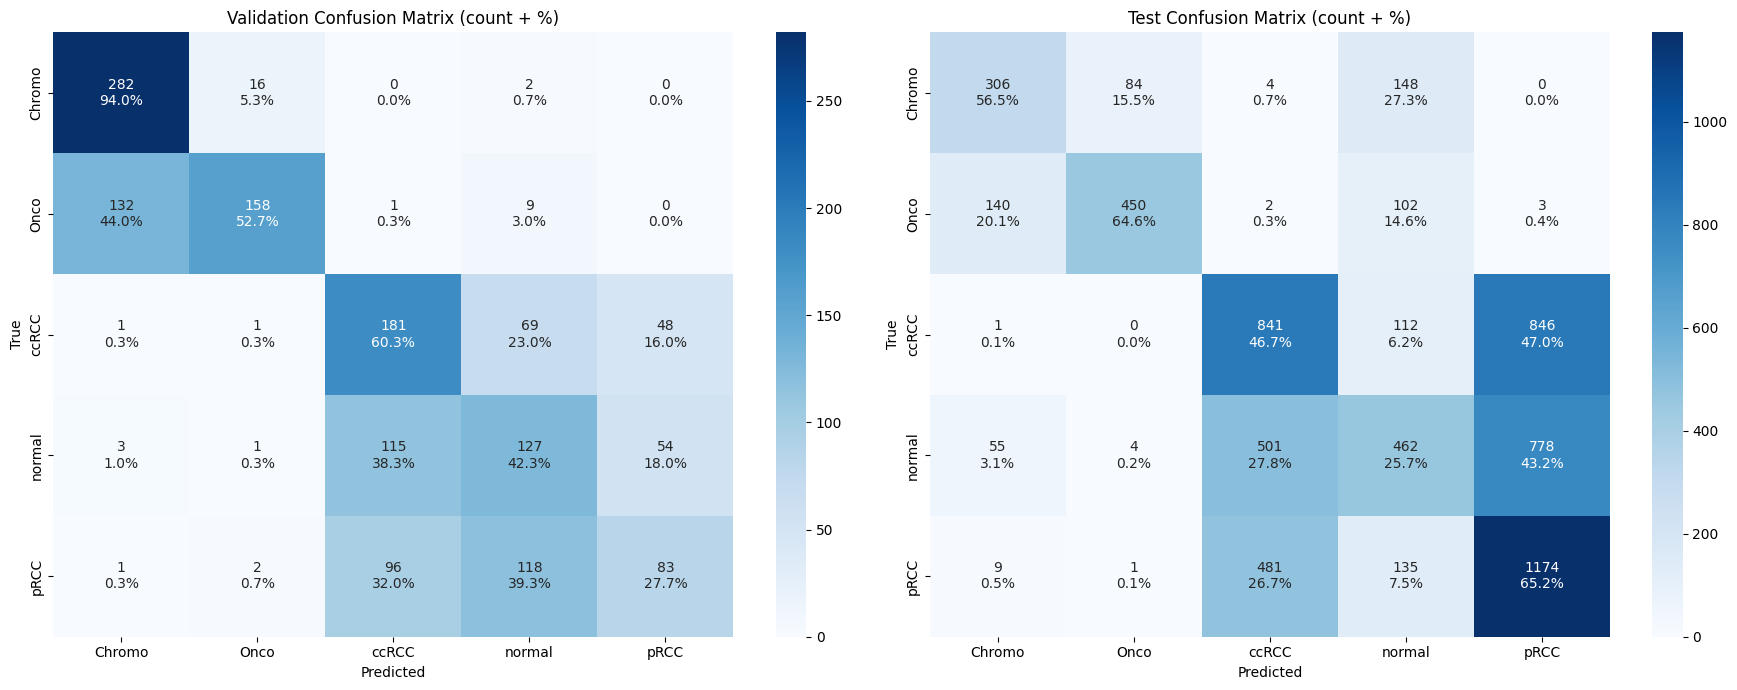

In [23]:
cm_val, labels_val = cm_with_percent_labels(y_val_true, y_val_pred, n_classes)
cm_test, labels_test = cm_with_percent_labels(y_test_true, y_test_pred, n_classes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm_val,
    annot=labels_val,
    fmt="",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("Validation Confusion Matrix (count + %)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_test,
    annot=labels_test,
    fmt="",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("Test Confusion Matrix (count + %)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [24]:
val_metrics = compute_metrics(y_val_true, y_val_pred)
test_metrics = compute_metrics(y_test_true, y_test_pred)

print("{:<18} {:>12} {:>12}".format("Metric", "VAL", "TEST"))
print("-"*44)
for k in val_metrics.keys():
    print("{:<18} {:>12.4f} {:>12.4f}".format(k, val_metrics[k], test_metrics[k]))

Metric                      VAL         TEST
--------------------------------------------
Accuracy                 0.5540       0.4870
Recall (macro)           0.5540       0.5173
F1 (macro)               0.5433       0.5236


# Part 3:  Deep Feature Extraction with a CNN

In [25]:
import torchvision.models as models
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50()

ckpt_path = "/kaggle/input/competitions/artificial-intelligencefor-histopathology/Histo images/best_ckpt.pth"

state_dict = torch.load(ckpt_path, map_location=device)

model.load_state_dict(state_dict, strict=False)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
import torch.nn as nn

feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device)

feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [27]:
def extract_deep_features(loader):
    all_features = []
    all_labels = []

    feature_extractor.eval()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            features = feature_extractor(images)          # [B, 2048, 1, 1]
            features = features.view(features.size(0), -1)  # [B, 2048]

            all_features.append(features.cpu())
            all_labels.append(labels)

    features = torch.cat(all_features, dim=0)
    labels = torch.cat(all_labels, dim=0)

    return features, labels

In [ ]:
X_train_deep, y_train_deep = extract_deep_features(train_loader)
X_val_deep, y_val_deep = extract_deep_features(val_loader)
X_test_deep, y_test_deep = extract_deep_features(test_loader)

print(X_train_deep.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_data_deep = TensorDataset(X_train_deep, y_train_deep)
val_data_deep = TensorDataset(X_val_deep, y_val_deep)
test_data_deep = TensorDataset(X_test_deep, y_test_deep)

train_loader_deep = DataLoader(train_data_deep, batch_size=64, shuffle=True)
val_loader_deep = DataLoader(val_data_deep, batch_size=64)
test_loader_deep = DataLoader(test_data_deep, batch_size=64)

In [ ]:
import torch.nn as nn

class DeepClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 5)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model_deep = DeepClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_deep.parameters(), lr=1e-3)

In [ ]:
epochs = 20

for epoch in range(epochs):
    model_deep.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader_deep:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_deep(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * features.size(0)

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model_deep.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader_deep:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model_deep(features)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * features.size(0)

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

In [ ]:
class_names = train_dataset.classes
n_classes = len(class_names)

y_val_true, y_val_pred = collect_preds(model_deep, val_loader_deep, device)
y_test_true, y_test_pred = collect_preds(model_deep, test_loader_deep, device)

cm_val, labels_val = cm_with_percent_labels(y_val_true, y_val_pred, n_classes)
cm_test, labels_test = cm_with_percent_labels(y_test_true, y_test_pred, n_classes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm_val,
    annot=labels_val,
    fmt="",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)

axes[0].set_title("Validation Confusion Matrix (count + %)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")


sns.heatmap(
    cm_test,
    annot=labels_test,
    fmt="",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)

axes[1].set_title("Test Confusion Matrix (count + %)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()